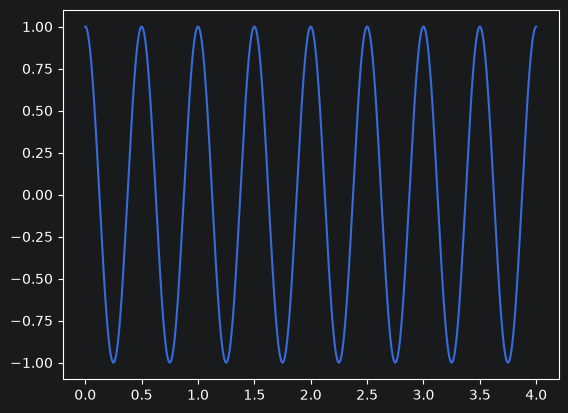

In [17]:
import numpy as np
from matplotlib import pyplot as plt
SR = 12000
T = 4
F = 2
A = 1
P = np.pi/2
def sine_generator(freq,amp,sample_rate,duration,phase):
    x = np.linspace(0,duration, sample_rate * duration, endpoint=False)
    y = amp*np.sin((2 * np.pi) * freq * x + phase)
    return x,y

x,y = sine_generator(F,A,SR,T,P)
plt.plot(x,y)
plt.show()

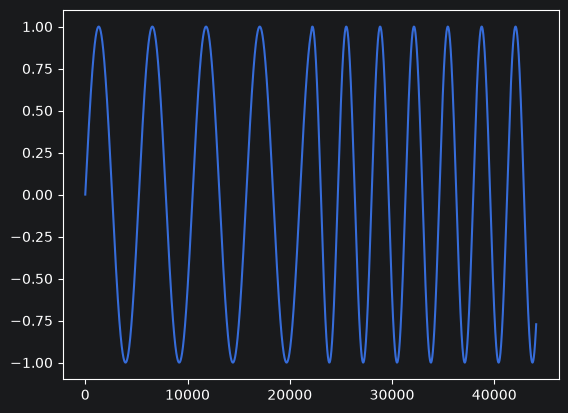

In [25]:
import numpy as np
from matplotlib import pyplot as plt
sr = 22050
ts = 1.0 / sr
duration = 1
t = np.arange(0, duration, ts)

# First segment
freq1 = 4.20
sine1 = 1 * np.sin(2 * np.pi * freq1 * t)

# Calculate phase offset based on the end of the first segment
phase_offset = 2 * np.pi * freq1 * duration

# Second segment with offset to maintain continuity
freq2 = 6.66
sine2 = 1 * np.sin(2 * np.pi * freq2 * t + phase_offset)

# Concatenate
plot_tone = np.concatenate([sine1, sine2])

plt.plot(plot_tone)
plt.show()

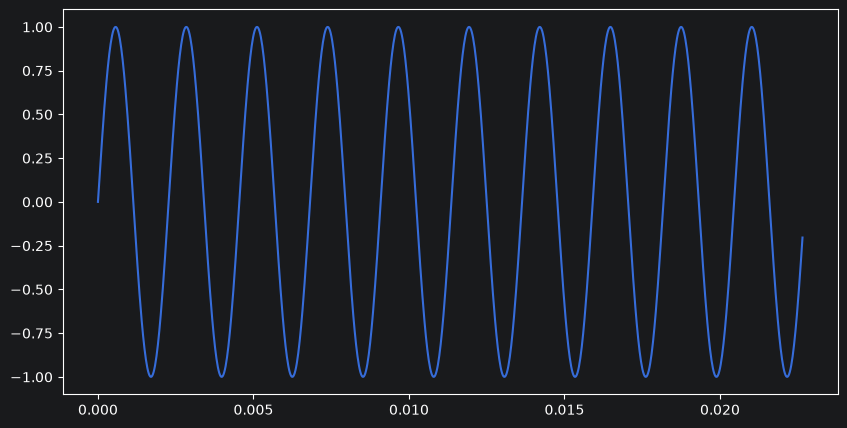

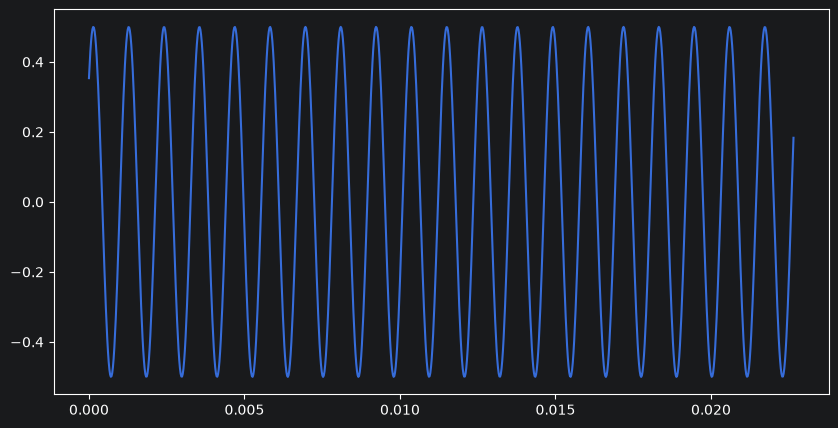

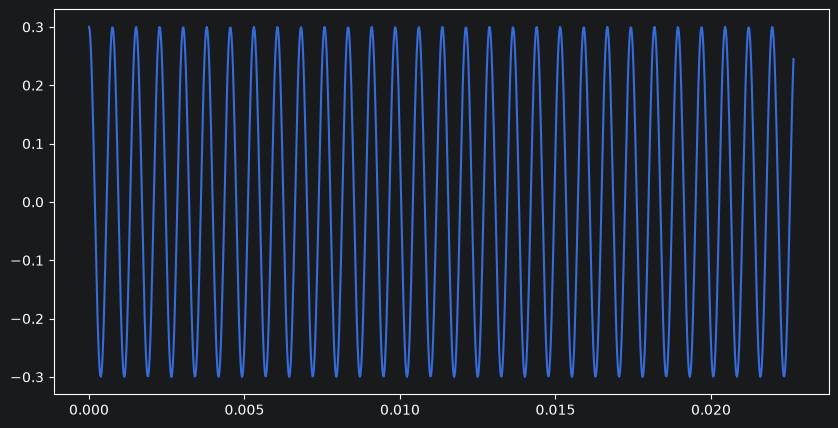

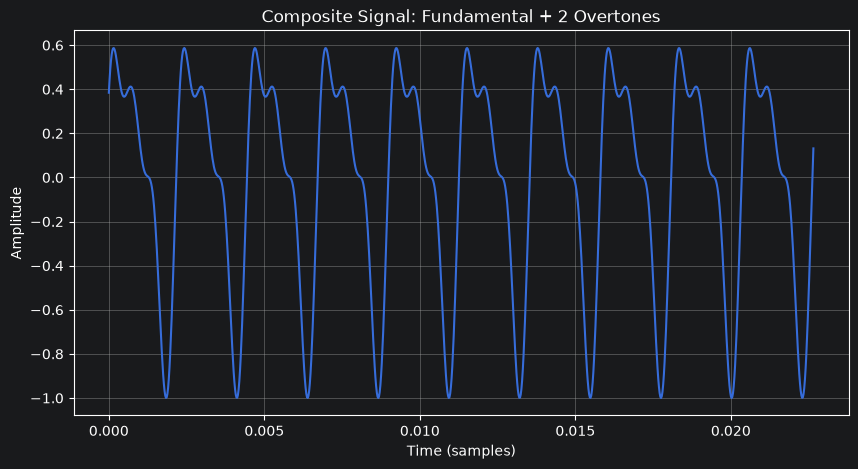

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define parameters
sr = 44100          # Sampling rate (Hz)
duration = 1.0      # Duration in seconds
f0 = 440            # Fundamental frequency (e.g., A4)

# Time vector
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# 2. Define component waves with different amplitudes and phases
# Formula: A * sin(2 * pi * f * t + phi)
amplitude1, phase1 = 1.0, 0
amplitude2, phase2 = 0.5, np.pi / 4   # 2nd harmonic (overtone)
amplitude3, phase3 = 0.3, np.pi / 2   # 3rd harmonic (overtone)

# 3. Generate individual sine waves
y1 = amplitude1 * np.sin(2 * np.pi * f0 * t + phase1)
y2 = amplitude2 * np.sin(2 * np.pi * (2 * f0) * t + phase2)
y3 = amplitude3 * np.sin(2 * np.pi * (3 * f0) * t + phase3)

# 4. Composite signal
composite_signal = y1 + y2 + y3

# Optional: Normalize to prevent clipping
composite_signal = composite_signal / np.max(np.abs(composite_signal))

# 5. Plotting
plt.figure(figsize=(10, 5))
plt.plot(t[:1000], y1[:1000])
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(t[:1000], y2[:1000])
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(t[:1000], y3[:1000])
plt.show()
plt.figure(figsize=(10, 5))
plt.plot(t[:1000], composite_signal[:1000]) # Plot first 1000 samples for clarity
plt.title('Composite Signal: Fundamental + 2 Overtones')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

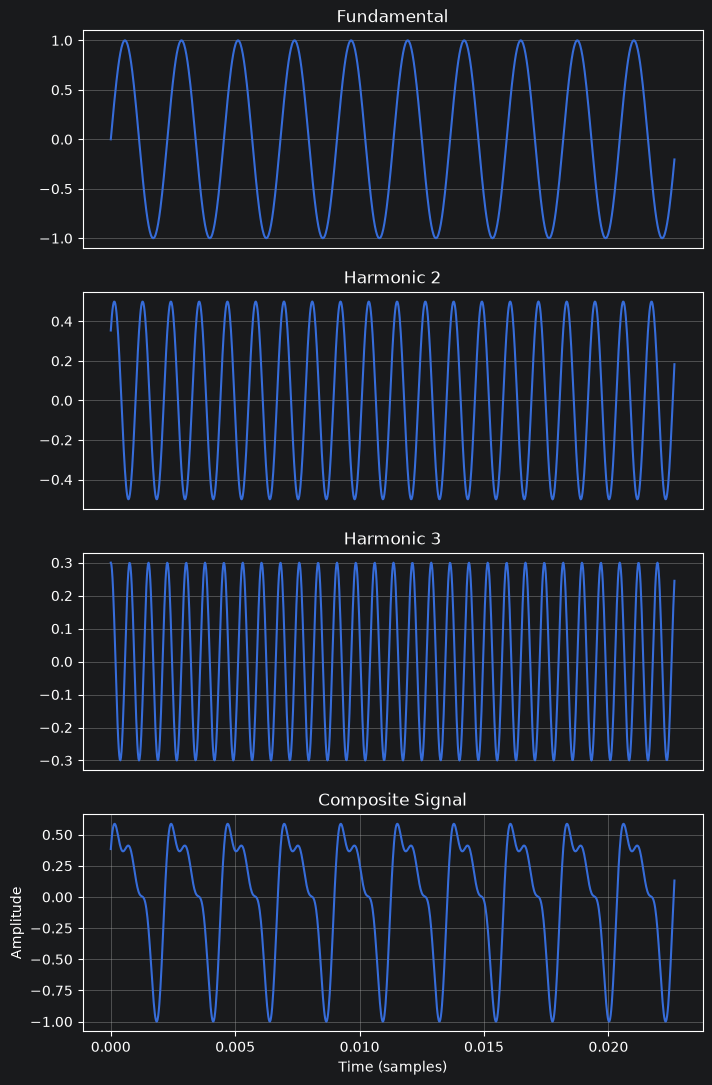

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters
sr, duration, f0 = 44100, 1.0, 440
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

# 2. Define harmonics: (amplitude, harmonic_index, phase)
harmonics = [
    (1.0, 1, 0),
    (0.5, 2, np.pi / 4),
    (0.3, 3, np.pi / 2)
]

# 3. Generate waves and composite signal
waves = []
for amp, n, phase in harmonics:
    waves.append(amp * np.sin(2 * np.pi * n * f0 * t + phase))

composite_signal = np.sum(waves, axis=0)
composite_signal /= np.max(np.abs(composite_signal))

# 4. Plot all signals in one figure
plt.figure(figsize=(8, 13))
for i, wave in enumerate(waves):
    plt.subplot(4, 1, i + 1)
    plt.plot(t[:1000], wave[:1000])
    plt.title(f'Harmonic {i+1}' if i > 0 else 'Fundamental')
    plt.grid(True)
    plt.xticks([]) # Hide x-axis labels for cleaner look

plt.subplot(4, 1, 4)
plt.plot(t[:1000], composite_signal[:1000])
plt.title('Composite Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.show()